### 1. Imports

In [1]:
#importando as bibliotecas
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math
import numpy as np
from scipy.integrate import trapezoid
from scipy.special import erf

### 2. Funções

In [2]:
#1° Função do estudo
def sen(x):
    """
    Brief: Calcula o seno de um número x

    Params:
        x: número utilizado na função

    Returns:
        retorna o seno de x
    """
    return math.sin(x)

In [3]:
#2° Função do estudo
def exponential(x):
    """
    Brief: Calcula a exponencial elevado a um número -x ao quadrado

    Params:
        x: número utilizado na função

    Returns:
        retorna o resultado de e elevado a -x ao quadrado
    """
    return np.exp(-x**2)

### 3. Aplicação na 1° função

In [4]:
exato_f1 = 2.0

In [5]:
#Criando a lista de subintervalos de 2 a 100
subintervalos = list(range(2, 101))
results = []

for n in subintervalos:
    #Gera n + 1 pontos igualmente espaçados de 0 a pi, aplica a função de seno em cada um desses pontos e aplica o método dos trapézios
    x_points = np.linspace(0, math.pi, n + 1)
    y_points = [sen(x) for x in x_points]
    resultado = trapezoid(y_points, x_points)
    results.append(resultado)

#Monta o DataFrame com os resultados
df_function_1 = pd.DataFrame({
    'n_subintervalos': subintervalos,
    'resultado': results 
})

#Calcula o erro absoluto para cada subintervalo
df_function_1['erro'] = np.abs(exato_f1 - df_function_1['resultado'])

In [6]:
df_function_1

,n_subintervalos,resultado,erro
0,2,1.570796,0.429204
1,3,1.813799,0.186201
2,4,1.896119,0.103881
3,5,1.933766,0.066234
4,6,1.954097,0.045903
...,...,...,...
94,96,1.999822,0.000178
95,97,1.999825,0.000175
96,98,1.999829,0.000171
97,99,1.999832,0.000168


Como visto na tabela, o menor erro dela é: 0.00016449611255664465. Com isso, o erro absoluto cai abaixo de 10^-4. Para conseguirmos um erro abaixo disso, aumentamos o n máximo. Assim, utilizando n = 129:

### 4. Aplicação na segunda função

In [7]:
df_tabela_pontos = None

In [8]:
#Criando a lista de subintervalos de 2 a 100
subintervalos = list(range(2, 101))
results = []

for n in subintervalos:
    #Gera n + 1 pontos igualmente espaçados de 0 a pi, aplica a função de seno em cada um desses pontos e aplica o método dos trapézios
    x_points = np.linspace(0, 2, n + 1)
    y_points = [exponential(x) for x in x_points]
    resultado = trapezoid(y_points, x_points)
    results.append(resultado)
    
    #Guarda a tabela exata de (xi, f(xi)) para N = 100
    if n == 100:
        df_tabela_pontos = pd.DataFrame({
            'i': range(n + 1),
            'x_i': x_points, 
            'f(x_i)': y_points
        })

#Monta o DataFrame apenas com os resultados das aproximações
df_function_2 = pd.DataFrame({
    'n_subintervalos': subintervalos,
    'resultado': results 
})

In [9]:
df_tabela_pontos

,i,x_i,f(x_i)
0,0,0.00,1.000000
1,1,0.02,0.999600
2,2,0.04,0.998401
3,3,0.06,0.996406
4,4,0.08,0.993620
...,...,...,...
96,96,1.92,0.025062
97,97,1.94,0.023200
98,98,1.96,0.021459
99,99,1.98,0.019833


In [10]:
#Calcula o valor da aproximação final para N = 100
aprox_n100 = df_function_2[df_function_2['n_subintervalos'] == 100]['resultado'].values[0]
print(f"Aproximação da integral para N=100: {aprox_n100:.6f}")

df_tabela_pontos = None

Aproximação da integral para N=100: 0.882079


### 5. Gráficos da função 1

#### 5.1 Gráfico de erro absoluto

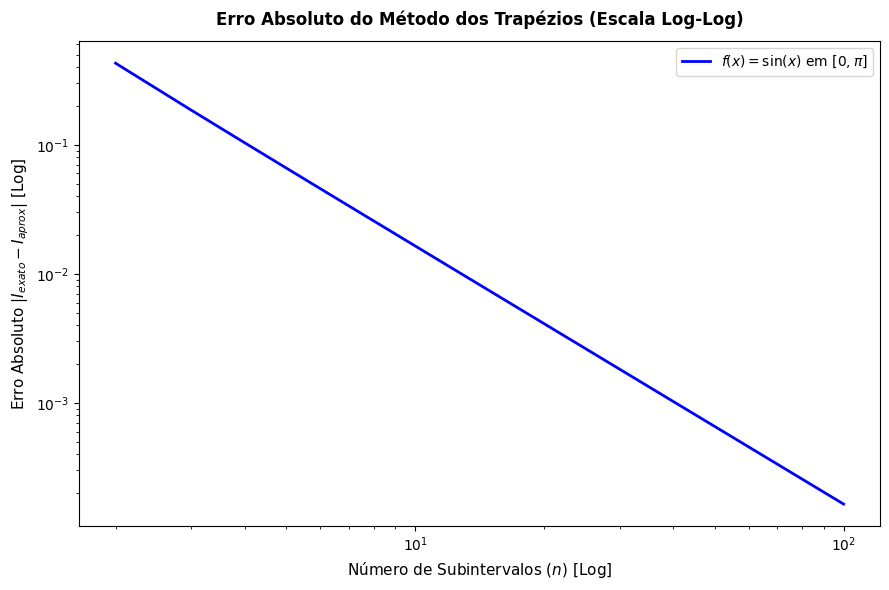

In [11]:
plt.figure(figsize=(9, 6))

sns.lineplot(
    data=df_function_1, 
    x='n_subintervalos', 
    y='erro', 
    label=r'$f(x) = \sin(x)$ em $[0, \pi]$', 
    color='b', 
    linewidth=2
)

plt.xscale('log')
plt.yscale('log')
plt.title('Erro Absoluto do Método dos Trapézios (Escala Log-Log)', fontsize=12, fontweight='bold', pad=12)
plt.xlabel('Número de Subintervalos ($n$) [Log]', fontsize=11)
plt.ylabel('Erro Absoluto $|I_{exato} - I_{aprox}|$ [Log]', fontsize=11)
plt.legend(fontsize=10)

plt.tight_layout()
plt.show()

O gráfico mostra que o bagulho só vai até 10^-3 com n = 100. A questão pede pra gente refinar até conseguir um erro menor que 10^-4. Pra isso, vou aumentar o n para 200.

In [12]:
#Criando a lista de subintervalos de 2 a 100
subintervalos = list(range(2, 201))
results = []

for n in subintervalos:
    #Gera n + 1 pontos igualmente espaçados de 0 a pi, aplica a função de seno em cada um desses pontos e aplica o método dos trapézios
    x_points = np.linspace(0, math.pi, n + 1)
    y_points = [sen(x) for x in x_points]
    resultado = trapezoid(y_points, x_points)
    results.append(resultado)

#Monta o DataFrame com os resultados
df_function_1 = pd.DataFrame({
    'n_subintervalos': subintervalos,
    'resultado': results 
})

#Calcula o erro absoluto para cada subintervalo
df_function_1['erro'] = np.abs(exato_f1 - df_function_1['resultado'])

In [13]:
df_function_1

,n_subintervalos,resultado,erro
0,2,1.570796,0.429204
1,3,1.813799,0.186201
2,4,1.896119,0.103881
3,5,1.933766,0.066234
4,6,1.954097,0.045903
...,...,...,...
194,196,1.999957,0.000043
195,197,1.999958,0.000042
196,198,1.999958,0.000042
197,199,1.999958,0.000042


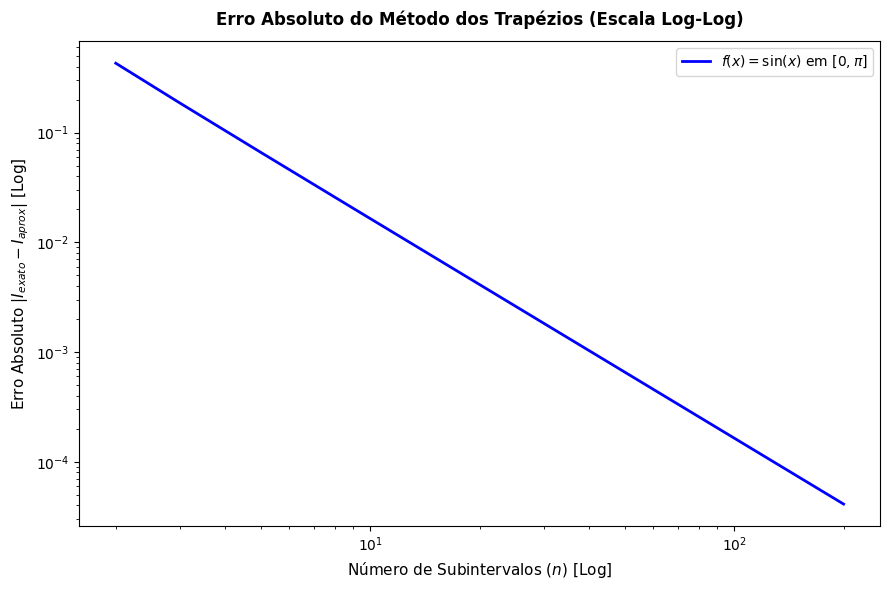

In [14]:
plt.figure(figsize=(9, 6))

sns.lineplot(
    data=df_function_1, 
    x='n_subintervalos', 
    y='erro', 
    label=r'$f(x) = \sin(x)$ em $[0, \pi]$', 
    color='b', 
    linewidth=2
)

plt.xscale('log')
plt.yscale('log')
plt.title('Erro Absoluto do Método dos Trapézios (Escala Log-Log)', fontsize=12, fontweight='bold', pad=12)
plt.xlabel('Número de Subintervalos ($n$) [Log]', fontsize=11)
plt.ylabel('Erro Absoluto $|I_{exato} - I_{aprox}|$ [Log]', fontsize=11)
plt.legend(fontsize=10)

plt.tight_layout()
plt.show()

#### 5.2 Gráfico de convergência

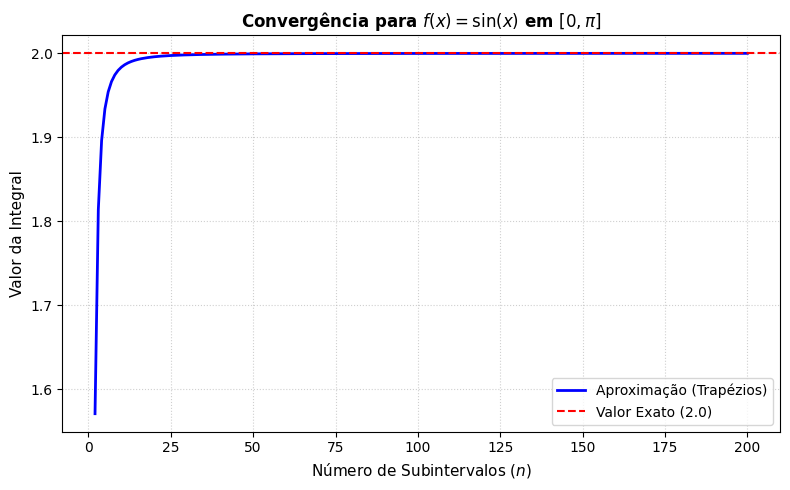

In [15]:
fig, ax = plt.subplots(figsize=(8, 5))

sns.lineplot(
    data=df_function_1, 
    x='n_subintervalos', 
    y='resultado', 
    ax=ax, 
    color='b', 
    linewidth=2, 
    label='Aproximação (Trapézios)'
)

ax.axhline(
    y=exato_f1, 
    color='r', 
    linestyle='--', 
    linewidth=1.5, 
    label=f'Valor Exato ({exato_f1})'
)

ax.set_title(r'Convergência para $f(x) = \sin(x)$ em $[0, \pi]$', fontsize=12, fontweight='bold')
ax.set_xlabel('Número de Subintervalos ($n$)', fontsize=11)
ax.set_ylabel('Valor da Integral', fontsize=11)
ax.legend(loc='lower right')
ax.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

#### 5.3 comparativo entre erro absoluto

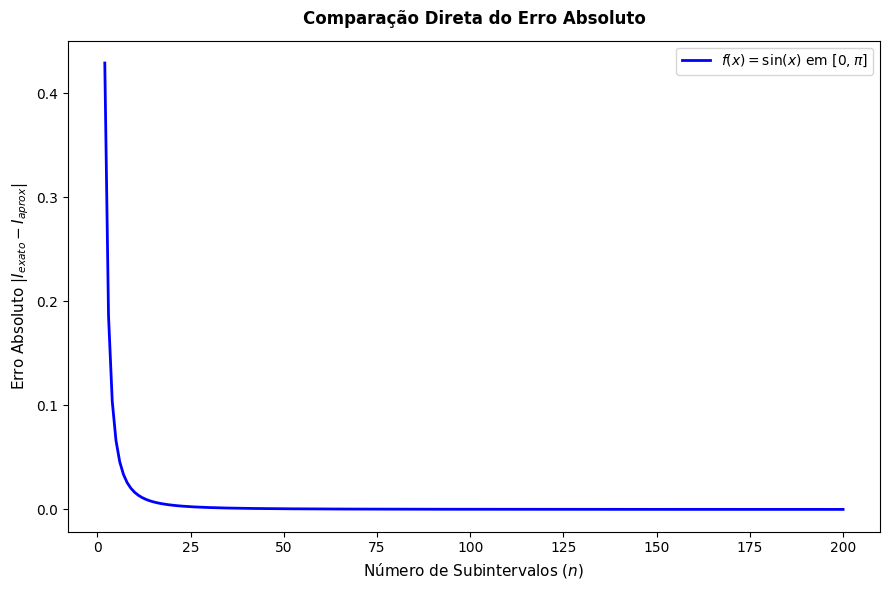

In [16]:
plt.figure(figsize=(9, 6))

sns.lineplot(
    data=df_function_1, 
    x='n_subintervalos', 
    y='erro', 
    label=r'$f(x) = \sin(x)$ em $[0, \pi]$', 
    color='b', 
    linewidth=2
)

plt.title('Comparação Direta do Erro Absoluto', fontsize=12, fontweight='bold', pad=12)
plt.xlabel('Número de Subintervalos ($n$)', fontsize=11)
plt.ylabel('Erro Absoluto $|I_{exato} - I_{aprox}|$', fontsize=11)
plt.legend(fontsize=10)

plt.tight_layout()
plt.show()

#### 5.4 erro relativo percentual

In [17]:
df_function_1['erro_relativo_%'] = (np.abs(exato_f1 - df_function_1['resultado']) / exato_f1) * 100

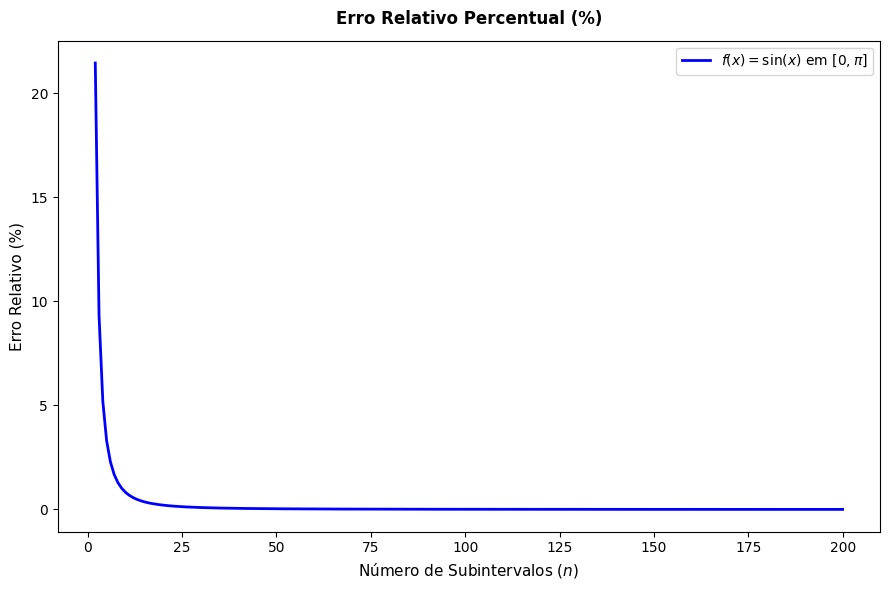

In [18]:
plt.figure(figsize=(9, 6))

sns.lineplot(
    data=df_function_1, 
    x='n_subintervalos', 
    y='erro_relativo_%', 
    label=r'$f(x) = \sin(x)$ em $[0, \pi]$', 
    color='b', 
    linewidth=2
)

plt.title('Erro Relativo Percentual (%)', fontsize=12, fontweight='bold', pad=12)
plt.xlabel('Número de Subintervalos ($n$)', fontsize=11)
plt.ylabel('Erro Relativo (%)', fontsize=11)
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()